In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('../data/AmesHousing.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (2930, 82)

First 5 rows:


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [2]:
# Show only columns that actually have missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f"Columns with missing values: {len(missing)}")
print(missing)

Columns with missing values: 27
Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Cond        159
Garage Yr Blt      159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
BsmtFin SF 1         1
BsmtFin SF 2         1
Electrical           1
Total Bsmt SF        1
Bsmt Unf SF          1
Garage Area          1
Garage Cars          1
dtype: int64


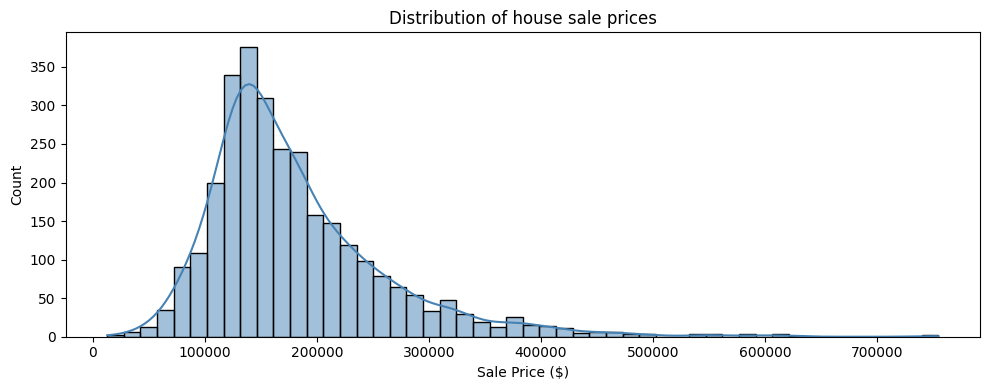

Average price: $180,796
Median price: $160,000
Min: $12,789
Max: $755,000


In [3]:
plt.figure(figsize=(10, 4))
sns.histplot(df['SalePrice'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of house sale prices')
plt.xlabel('Sale Price ($)')
plt.tight_layout()
plt.savefig('../visuals/01_price_distribution.png', dpi=150)
plt.show()

print(f"Average price: ${df['SalePrice'].mean():,.0f}")
print(f"Median price: ${df['SalePrice'].median():,.0f}")
print(f"Min: ${df['SalePrice'].min():,.0f}")
print(f"Max: ${df['SalePrice'].max():,.0f}")

Skewness: 1.74


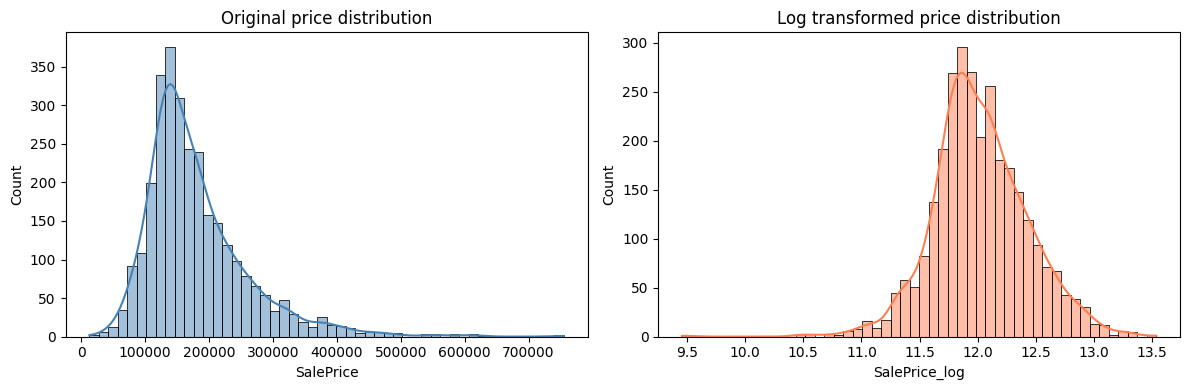

In [4]:
import scipy.stats as stats

print(f"Skewness: {df['SalePrice'].skew():.2f}")

# Log transform the price to reduce skew
df['SalePrice_log'] = np.log1p(df['SalePrice'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['SalePrice'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Original price distribution')
sns.histplot(df['SalePrice_log'], bins=50, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Log transformed price distribution')
plt.tight_layout()
plt.savefig('../visuals/02_price_skew.png', dpi=150)
plt.show()

In [6]:
# Get numeric columns only
numeric_df = df.select_dtypes(include=[np.number])

# Correlations with SalePrice
correlations = numeric_df.corr()['SalePrice'].sort_values(ascending=False)
print("Top 15 features correlated with price:")
print(correlations.head(15))

Top 15 features correlated with price:
SalePrice         1.000000
SalePrice_log     0.946304
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Mas Vnr Area      0.508285
TotRms AbvGrd     0.495474
Fireplaces        0.474558
Name: SalePrice, dtype: float64
